Импорт библиотек, Загрузка изображений, Вспомогательные функции

Карта: (884, 1180), Кадр: (884, 878)


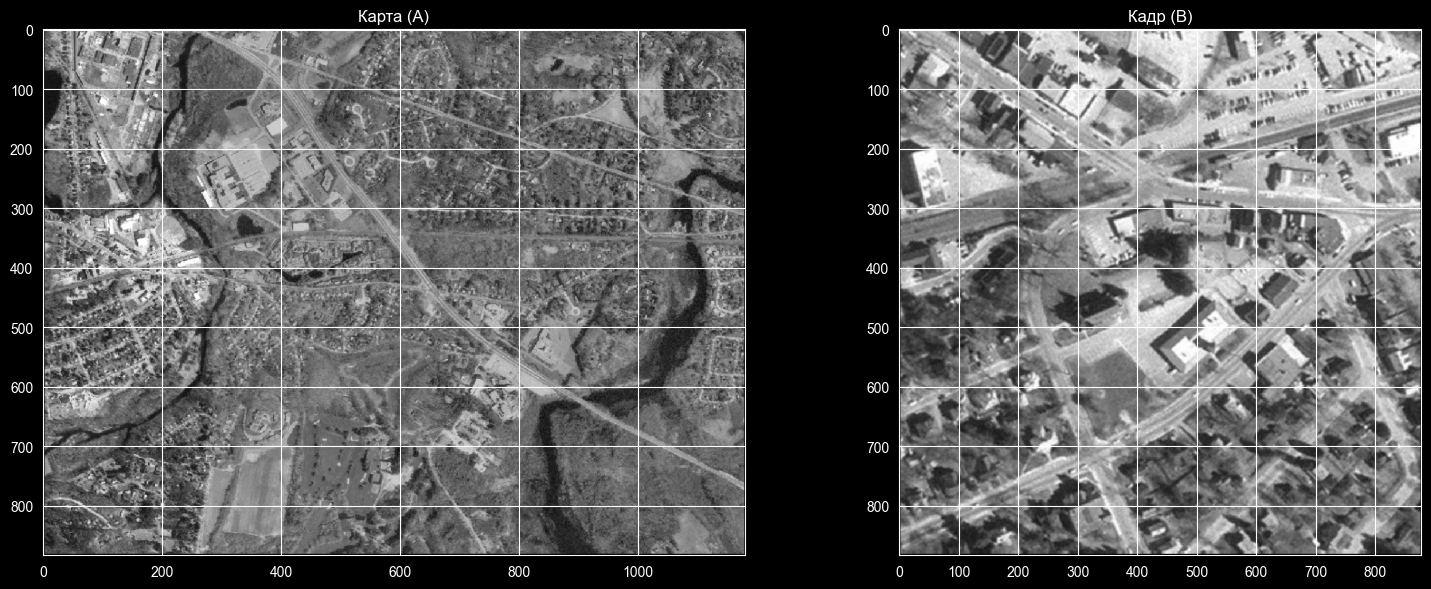

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage
from scipy.ndimage import rotate, zoom, uniform_filter
from scipy.signal import fftconvolve
from PIL import Image
from tqdm import tqdm
import time
import warnings
import cv2
from numba import njit, prange
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

# Замените пути на ваши файлы
# Первое загруженное изображение — кадр (WestConcordOrthoPhoto.png)
# Второе — карта (ConcordOrthoPhoto.png)

map_img   = np.array(Image.open('ConcordOrthoPhoto.png').convert('L'))
frame_img = np.array(Image.open('WestConcordOrthoPhoto.png').convert('L'))

print(f"Карта: {map_img.shape}, Кадр: {frame_img.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(map_img, cmap='gray'); axes[0].set_title('Карта (A)')
axes[1].imshow(frame_img, cmap='gray'); axes[1].set_title('Кадр (B)')
plt.tight_layout()
plt.show()

SCALE = 5.75
frame_img = cv2.resize(frame_img, None, fx=1 / SCALE, fy=1 / SCALE, interpolation=cv2.INTER_AREA)

def edge_sobel(img):
    """Аналог MATLAB edge(img, 'Sobel')"""
    img_f = img.astype(np.float64)
    sx = ndimage.sobel(img_f, axis=1)
    sy = ndimage.sobel(img_f, axis=0)
    mag = np.sqrt(sx**2 + sy**2)
    # Автоматический порог (как в MATLAB)
    thr = np.percentile(mag[mag > 0], 85)
    return (mag > thr).astype(np.uint8)

def imgradient_sobel(img):
    """Аналог MATLAB [G, gamma] = imgradient(img, 'Sobel')"""
    img_f = img.astype(np.float64)
    sx = ndimage.sobel(img_f, axis=1)
    sy = ndimage.sobel(img_f, axis=0)
    G = np.sqrt(sx**2 + sy**2)
    gamma = np.degrees(np.arctan2(-sy, sx))  # диапазон [-180, 180]
    return G, gamma

def find_max_position(H):
    """Найти координаты максимального отклика в ПП"""
    idx = np.unravel_index(np.argmax(H), H.shape)
    return idx  # (dy, dx)

def display_result(map_img, frame_img, pos, title='',
                   edge_color='red', edge_width=2, alpha=0.8):
    """
    Отображает карту с выделенной рамкой положения кадра.
    Сам кадр НЕ вставляется в карту — рисуется только контур.

    Параметры:
        map_img    — изображение карты (2D numpy массив)
        frame_img  — изображение кадра (нужно только для размеров h1, w1)
        pos        — (dy, dx) положение левого верхнего угла кадра на карте
        title      — заголовок графика
        edge_color — цвет рамки (matplotlib color)
        edge_width — толщина линии рамки
        alpha      — прозрачность рамки
    """
    dy, dx = pos
    h1, w1 = frame_img.shape

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(map_img, cmap='gray')

    # Рисуем прямоугольник-рамку поверх карты
    rect = patches.Rectangle(
        (dx, dy),          # левый нижний угол в координатах matplotlib (x, y)
        w1,                # ширина
        h1,                # высота
        linewidth=edge_width,
        edgecolor=edge_color,
        facecolor='none',  # без заливки — только контур
        alpha=alpha
    )
    ax.add_patch(rect)

    # Подпись с координатами
    ax.text(dx + 5, dy - 10,
            f'dy={dy}, dx={dx}  (h={h1}, w={w1})',
            color='yellow', fontsize=10,
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


GHT без направления градиента

=== ЧАСТЬ 1: GHT без направления градиента ===

Точек контура карты: 155668, кадра: 3534
Время расчёта: 0.18 сек

Положение макс. отклика: dy=361, dx=84
Величина макс. отклика: 1987


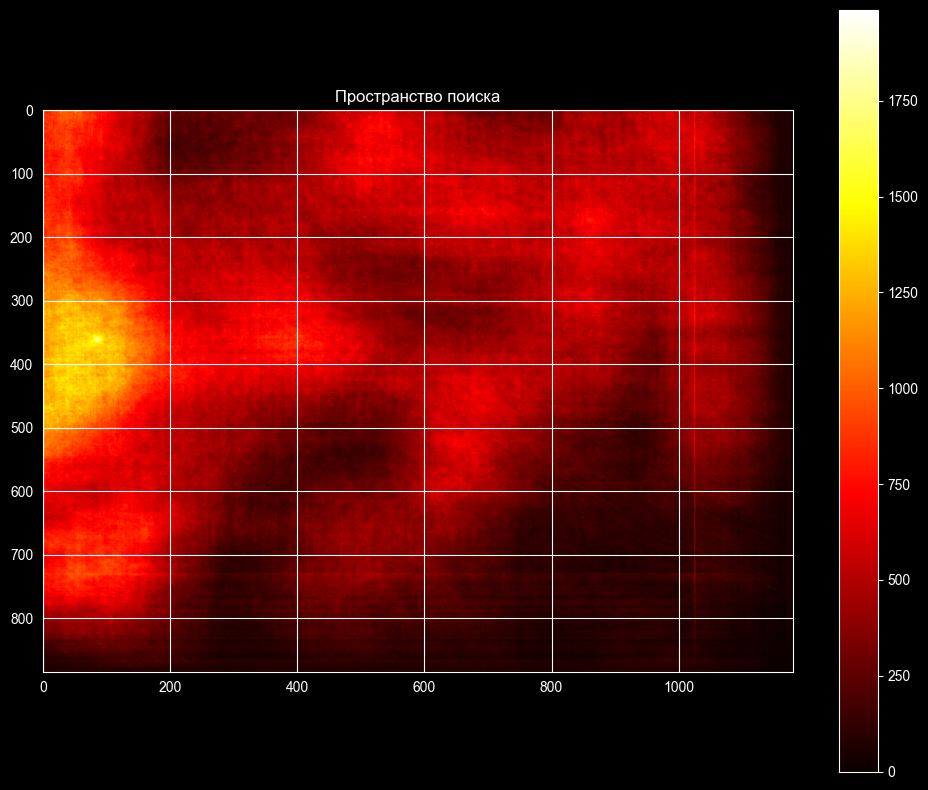

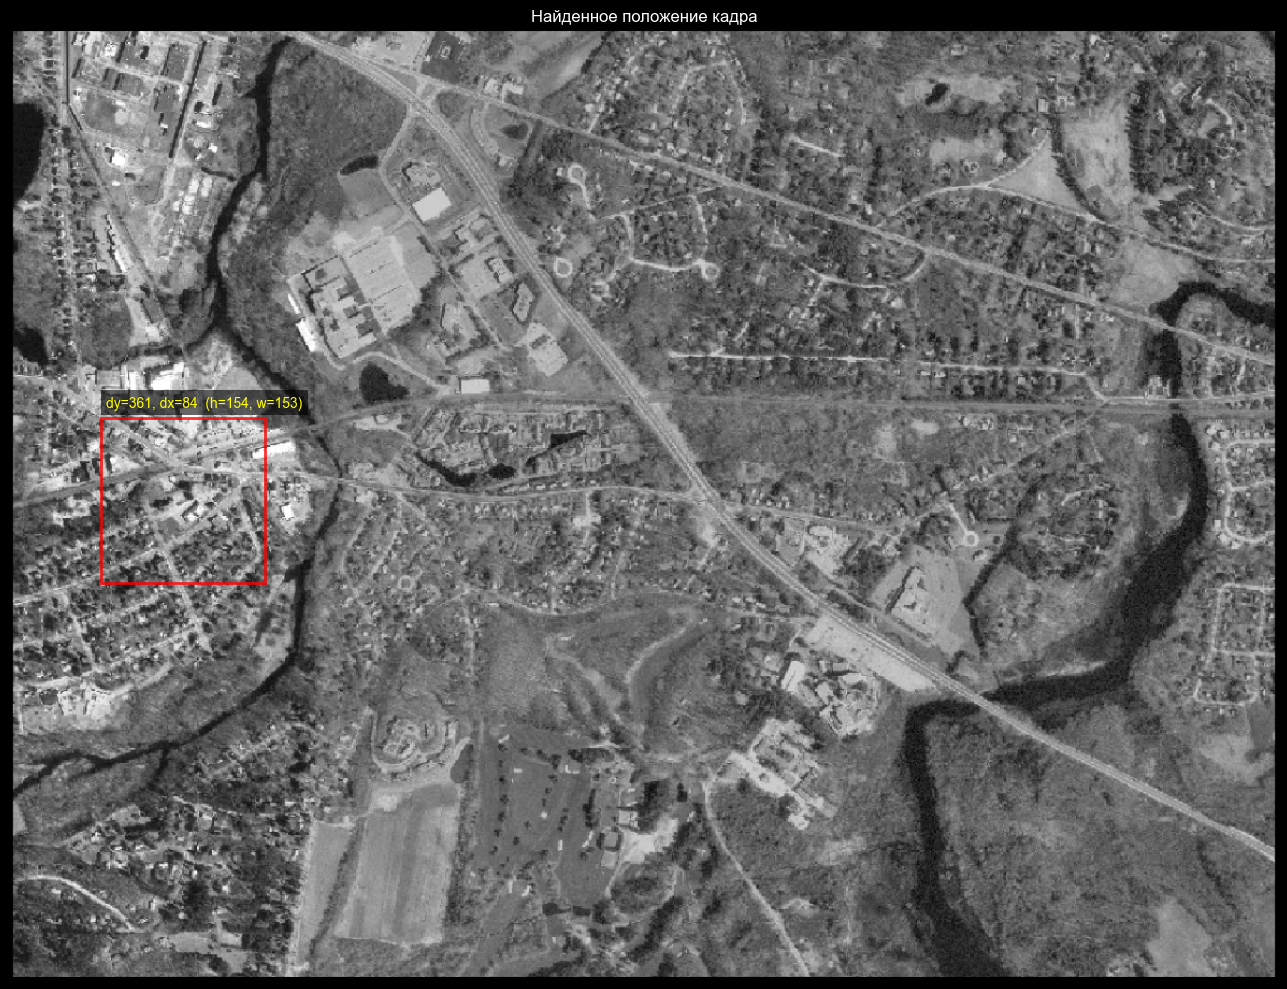

In [73]:
def FindGHT_true(A, B):
    """
    FindGHT — вычисляет GHT кадра и карты без использования направления градиента.
    A — карта, B — кадр
    """
    h, w = A.shape
    h1, w1 = B.shape
    H = np.zeros((h, w), dtype=np.int32)

    Ca = edge_sobel(A)
    Cb = edge_sobel(B)

    y, x = np.where(Ca == 1)
    y1, x1 = np.where(Cb == 1)
    n = len(x)
    n1 = len(x1)
    print(f"Точек контура карты: {n}, кадра: {n1}")

    for i in tqdm(range(n)):
        for j in range(n1):
            dx = int(x[i] - x1[j])
            dy = int(y[i] - y1[j])
            if 0 <= dx < w and 0 <= dy < h:
                H[dy, dx] += 1
    return H

@njit(parallel=True, cache=True)
def _findght_core(x, y, x1, y1, h, w):
    """
    Вычисляет пространство поиска H методом GHT (без направления градиента).
    Внешний цикл по точкам карты распараллелен через prange.

    Параметры:
        x, y   - координаты точек контура карты  (массивы int64)
        x1, y1 - координаты точек контура кадра  (массивы int64)
        h, w   - размеры карты (высота, ширина)
    Возвращает:
        H      - пространство поиска (массив int32 размера h x w)
    """
    H = np.zeros((h, w), dtype=np.int32)
    n  = x.shape[0]
    n1 = x1.shape[0]

    # prange — параллельный аналог range (распределяет итерации по потокам)
    for i in prange(n):
        xi = x[i]
        yi = y[i]
        for j in range(n1):
            dx = xi - x1[j]
            dy = yi - y1[j]
            # В Python индексация с 0, поэтому условие: 0 <= dx < w
            if 0 <= dx < w and 0 <= dy < h:
                H[dy, dx] += 1
    return H

def FindGHT(A, B):
    """
    Аналог MATLAB FindGHT(A, B) с ускорением через numba.
    A — карта, B — кадр (numpy массивы uint8).
    """
    h, w = A.shape

    # Находим контуры (обычный Python, numba здесь не нужен)
    Ca = edge_sobel(A)
    Cb = edge_sobel(B)

    # Получаем координаты точек контура
    y,  x  = np.where(Ca == 1)
    y1, x1 = np.where(Cb == 1)

    n  = x.shape[0]
    n1 = x1.shape[0]
    print(f"Точек контура карты: {n}, кадра: {n1}")

    # ВАЖНО: numba требует явного указания типов. Приводим к int64.
    x  = x.astype(np.int64)
    y  = y.astype(np.int64)
    x1 = x1.astype(np.int64)
    y1 = y1.astype(np.int64)

    # Вызов JIT-компилированного ядра
    H = _findght_core(x, y, x1, y1, h, w)
    return H

print("=== ЧАСТЬ 1: GHT без направления градиента ===\n")
t0 = time.time()
H1 = FindGHT(map_img, frame_img)
t1 = time.time()
print(f"Время расчёта: {t1 - t0:.2f} сек\n")

pos1 = find_max_position(H1)
print(f"Положение макс. отклика: dy={pos1[0]}, dx={pos1[1]}")
print(f"Величина макс. отклика: {H1[pos1]}")

# Визуализация ПП
plt.figure(figsize=(10, 8))
plt.imshow(H1, cmap='hot')
plt.colorbar()
plt.title('Пространство поиска')
plt.tight_layout()
plt.show()

display_result(map_img, frame_img, pos1, 'Найденное положение кадра')

GHT с направлением градиента

=== ЧАСТЬ 2: GHT с направлением градиента ===

Время расчёта: 0.17 сек

Положение макс. отклика: dy=360, dx=83
Величина макс. отклика: 155


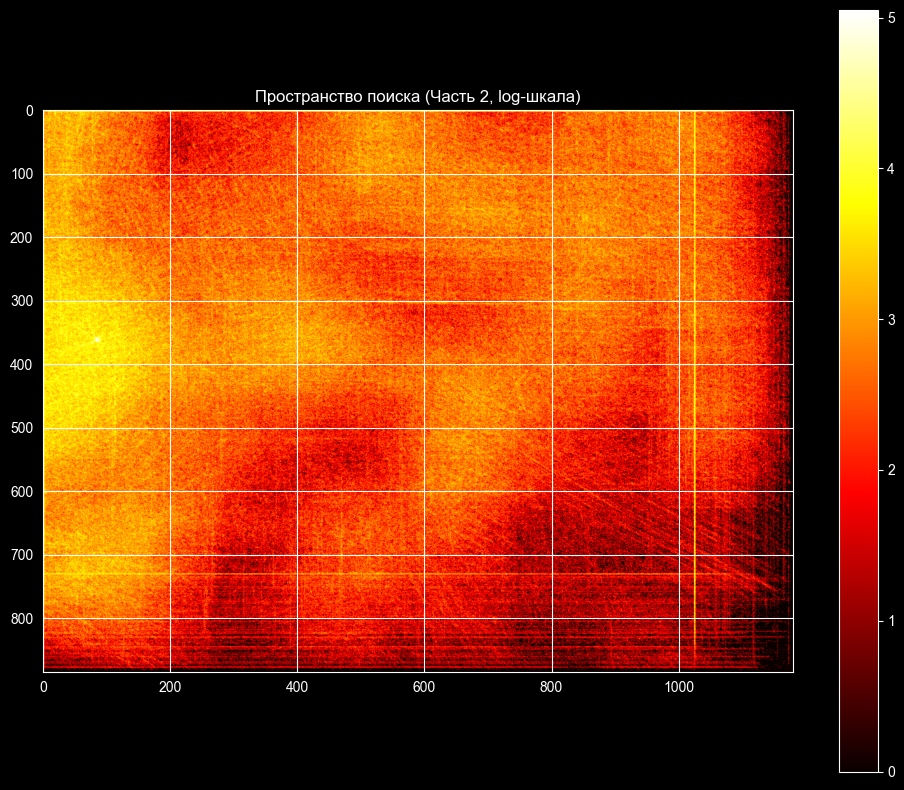

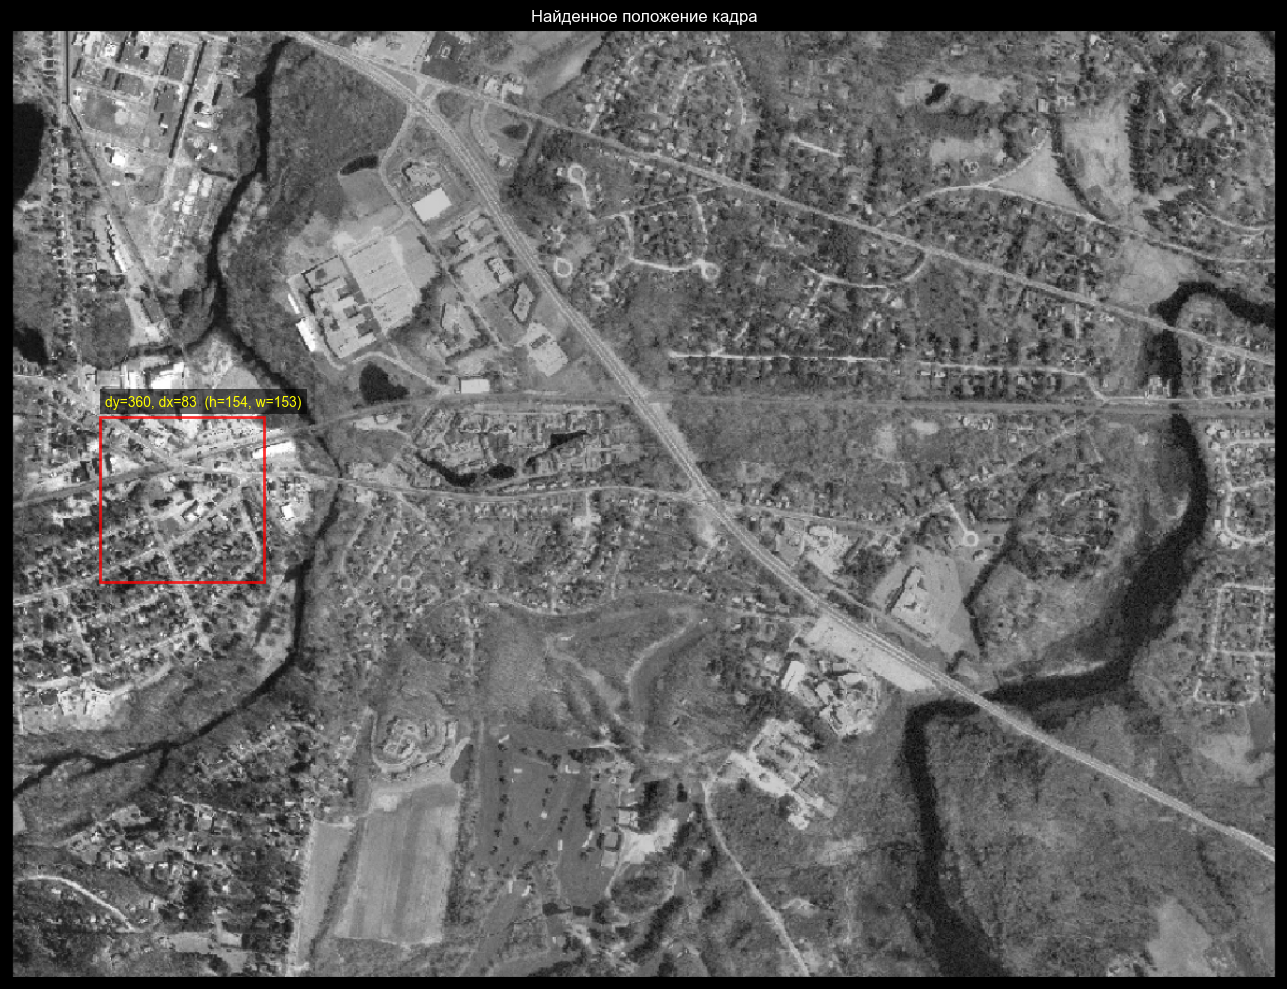

In [74]:
def qsort(a, b, gb, x1, y1):
    """Рекурсивная быстрая сортировка (аналог вложенной функции в MATLAB)"""
    L = a
    R = b
    m = gb[(a + b) // 2]
    while L <= R:
        while gb[L] < m:
            L += 1
        while gb[R] > m:
            R -= 1
        if L <= R:
            gb[L], gb[R] = gb[R], gb[L]
            x1[L], x1[R] = x1[R], x1[L]
            y1[L], y1[R] = y1[R], y1[L]
            L += 1
            R -= 1
    if a < R:
        qsort(a, R, gb, x1, y1)
    if L < b:
        qsort(L, b, gb, x1, y1)

def FindGHT2_true(A, B, eps_deg=5):
    """
    FindGHT2 — GHT с использованием направления градиента.
    A — карта, B — кадр
    eps_deg — допуск по направлению градиента (градусы)
    """
    h, w = A.shape
    H = np.zeros((h, w), dtype=np.int32)

    # Границы
    Ca = edge_sobel(A)
    Cb = edge_sobel(B)

    # Направление градиента
    _, gammaA = imgradient_sobel(A)
    _, gammaB = imgradient_sobel(B)

    # Списки координат
    y, x = np.where(Ca == 1)
    y1, x1 = np.where(Cb == 1)
    n = len(x)
    n1 = len(x1)

    # Списки направлений градиента
    ga = np.array([gammaA[y[i], x[i]] for i in range(n)])
    gb = np.array([gammaB[y1[i], x1[i]] for i in range(n1)])

    # Сортировка точек кадра по направлению градиента (quicksort)
    if n1 > 1:
        qsort(0, n1 - 1, gb, x1, y1)

    # Формирование закладок (bookmarks) через 1 градус
    N = 360
    Q = np.zeros(N + 1, dtype=int)
    Q[0] = 0
    for i in range(1, N + 1):
        Q[i] = Q[i - 1]
        q_val = (i - 1) - 180  # от -180 до 179
        for j in range(Q[i - 1], n1):
            if gb[j] > q_val:
                Q[i] = j
                break
    Q[N] = n1  # терминальная закладка

    # Преобразование Хафа
    for i in range(n):  # для каждой точки карты
        f = ga[i]
        q = int(round(f + 180))  # пересчёт фазы в номер закладки
        q1 = max(0, q - eps_deg)
        q2 = min(N, q + eps_deg)
        for j in range(Q[q1], Q[q2]):
            dx = int(x[i] - x1[j])
            dy = int(y[i] - y1[j])
            if 0 <= dx < w and 0 <= dy < h:
                H[dy, dx] += 1

    return H

from numba import njit, prange

@njit(parallel=True, cache=True)
def _findght2_numba(x, y, x1, y1, ga, gb_sorted, Q, h, w, eps_deg):
    """Полностью скомпилированная и распараллеленная версия FindGHT2."""
    H = np.zeros((h, w), dtype=np.int64)
    n = len(x)
    for i in prange(n):          # ← prange = параллельный range
        f = ga[i]
        q = int(np.round(f + 180))
        q1 = q - eps_deg
        if q1 < 0:   q1 = 0
        q2 = q + eps_deg
        if q2 > 360: q2 = 360
        idx_start = Q[q1]
        idx_end   = Q[q2]
        xi = x[i]; yi = y[i]
        for j in range(idx_start, idx_end):
            dx = xi - x1[j]
            dy = yi - y1[j]
            if 0 <= dx < w and 0 <= dy < h:
                H[dy, dx] += 1
    return H


def FindGHT2(A, B, eps_deg=5):
    h, w = A.shape
    Ca = edge_sobel(A)
    Cb = edge_sobel(B)
    _, gammaA = imgradient_sobel(A)
    _, gammaB = imgradient_sobel(B)
    y, x = np.where(Ca == 1)
    y1, x1 = np.where(Cb == 1)
    n = len(x); n1 = len(x1)
    ga = np.array([gammaA[y[i], x[i]] for i in range(n)], dtype=np.float64)
    gb = np.array([gammaB[y1[i], x1[i]] for i in range(n1)], dtype=np.float64)

    order = np.argsort(gb)
    gb = gb[order]; x1 = x1[order].astype(np.int64); y1 = y1[order].astype(np.int64)

    N = 360
    Q = np.zeros(N + 1, dtype=np.int64)
    Q[0] = 0
    for i in range(1, N + 1):
        Q[i] = Q[i - 1]
        q_val = (i - 1) - 180
        for j in range(Q[i - 1], n1):
            if gb[j] > q_val:
                Q[i] = j
                break
    Q[N] = n1

    # Первый вызов — компиляция (медленно), дальнейшие — мгновенно
    H = _findght2_numba(x.astype(np.int64), y.astype(np.int64),
                        x1, y1, ga, gb, Q, h, w, eps_deg)
    return H

print("=== ЧАСТЬ 2: GHT с направлением градиента ===\n")
t0 = time.time()
H2 = FindGHT2(map_img, frame_img, eps_deg=5)
t1 = time.time()
print(f"Время расчёта: {t1 - t0:.2f} сек\n")

pos2 = find_max_position(H2)
print(f"Положение макс. отклика: dy={pos2[0]}, dx={pos2[1]}")
print(f"Величина макс. отклика: {H2[pos2]}")

# Визуализация ПП (логарифмическая шкала для видимости)
plt.figure(figsize=(10, 8))
plt.imshow(np.log1p(H2), cmap='hot')
plt.colorbar()
plt.title('Пространство поиска (Часть 2, log-шкала)')
plt.tight_layout()
plt.show()

display_result(map_img, frame_img, pos2, 'Найденное положение кадра')

Спектральный метод

In [75]:
def spectral_correlation(map_img, frame_img):
    """Нормализованная кросс-корреляция через FFT (спектральный метод)"""
    A = map_img.astype(np.float64)
    B = frame_img.astype(np.float64)
    A = (A - A.mean()) / (A.std() + 1e-10)
    B = (B - B.mean()) / (B.std() + 1e-10)
    corr = fftconvolve(A, B[::-1, ::-1], mode='valid')
    return corr

def find_true_position(map_img, frame_img):
    """Найти заведомо верное положение через спектральный метод"""
    corr = spectral_correlation(map_img, frame_img)
    idx = np.unravel_index(np.argmax(corr), corr.shape)
    return idx  # (dy, dx) в координатах 'valid' корреляции

true_pos = find_true_position(map_img, frame_img)
print(f"Заведомо верное положение (спектральный метод): dy={true_pos[0]}, dx={true_pos[1]}")

Заведомо верное положение (спектральный метод): dy=361, dx=84


Исследование поворота

=== Исследование влияния поворота ===



100%|██████████| 25/25 [00:06<00:00,  4.16it/s]


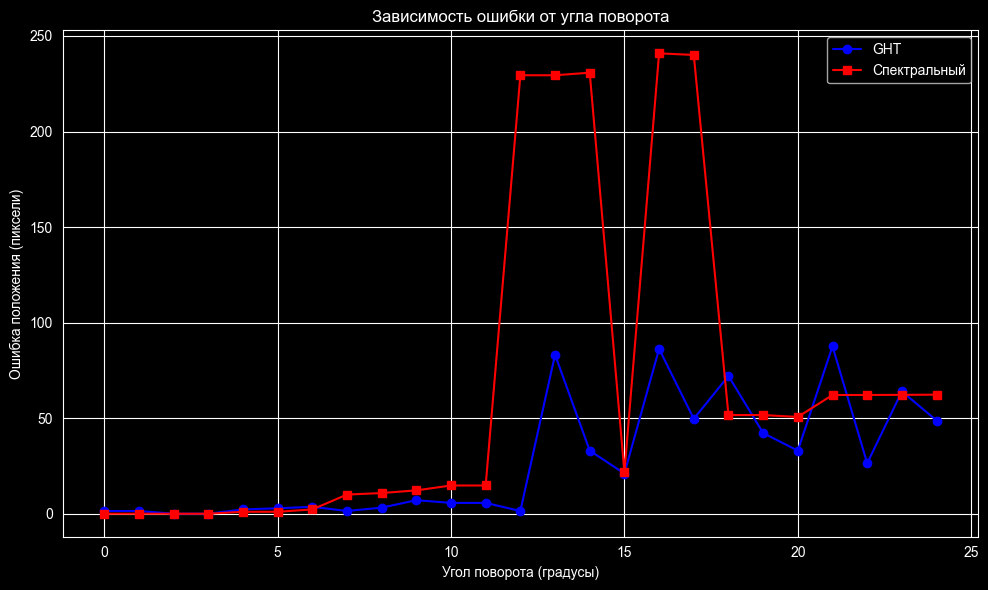

In [76]:
print("=== Исследование влияния поворота ===\n")
angles = np.arange(0, 25, 1)
errors_rot_ght = []
errors_rot_spec = []

for angle in tqdm(angles):
    rotated = rotate(frame_img, angle, reshape=False, cval=0, order=1)

    # GHT
    H_rot = FindGHT2(map_img, rotated, eps_deg=5)
    pos_rot = find_max_position(H_rot)
    err_ght = np.sqrt((pos_rot[0] - true_pos[0])**2 + (pos_rot[1] - true_pos[1])**2)
    errors_rot_ght.append(err_ght)

    # Спектральный
    corr_rot = spectral_correlation(map_img, rotated)
    pos_spec = np.unravel_index(np.argmax(corr_rot), corr_rot.shape)
    err_spec = np.sqrt((pos_spec[0] - true_pos[0])**2 + (pos_spec[1] - true_pos[1])**2)
    errors_rot_spec.append(err_spec)

    # print(f"Угол {angle:2d}°: GHT err={err_ght:.1f}, Spectral err={err_spec:.1f}")

plt.figure(figsize=(10, 6))
plt.plot(angles, errors_rot_ght, 'b-o', label='GHT')
plt.plot(angles, errors_rot_spec, 'r-s', label='Спектральный')
plt.xlabel('Угол поворота (градусы)')
plt.ylabel('Ошибка положения (пиксели)')
plt.title('Зависимость ошибки от угла поворота')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Исследование масштаба

=== Исследование влияния масштаба ===



100%|██████████| 13/13 [00:03<00:00,  3.90it/s]


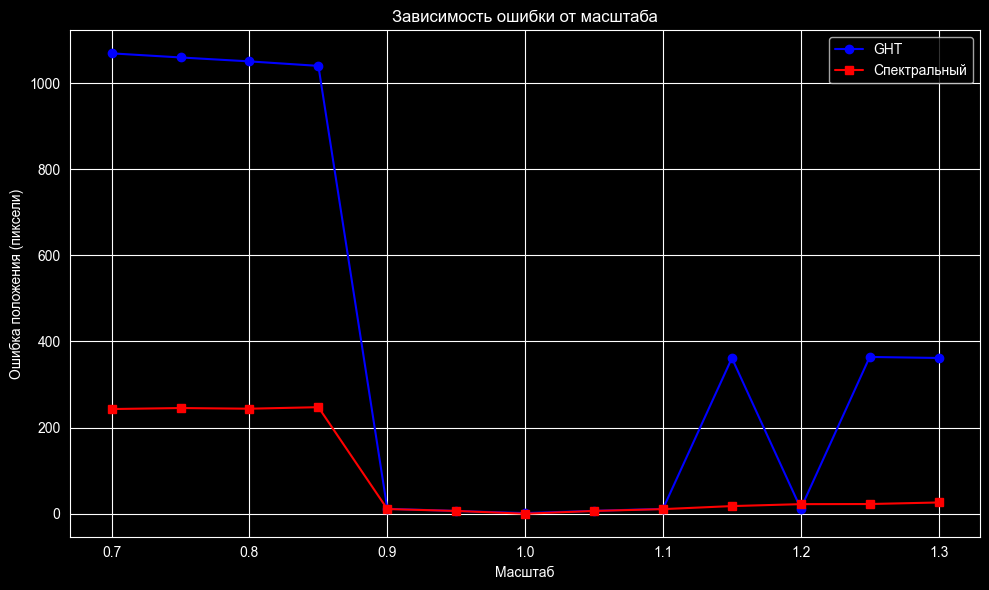

In [77]:
print("=== Исследование влияния масштаба ===\n")
scales = np.arange(0.7, 1.31, 0.05)
errors_scale_ght = []
errors_scale_spec = []

for s in tqdm(scales):
    scaled = zoom(frame_img, s, order=1)
    # Привести к исходному размеру (дополнить нулями или обрезать)
    h1, w1 = frame_img.shape
    scaled_resized = np.zeros_like(frame_img)
    sh, sw = scaled.shape
    h_min = min(h1, sh)
    w_min = min(w1, sw)
    scaled_resized[:h_min, :w_min] = scaled[:h_min, :w_min]

    # GHT
    H_sc = FindGHT2(map_img, scaled_resized, eps_deg=5)
    pos_sc = find_max_position(H_sc)
    err_ght = np.sqrt((pos_sc[0] - true_pos[0])**2 + (pos_sc[1] - true_pos[1])**2)
    errors_scale_ght.append(err_ght)

    # Спектральный
    corr_sc = spectral_correlation(map_img, scaled_resized)
    pos_spec = np.unravel_index(np.argmax(corr_sc), corr_sc.shape)
    err_spec = np.sqrt((pos_spec[0] - true_pos[0])**2 + (pos_spec[1] - true_pos[1])**2)
    errors_scale_spec.append(err_spec)

    # print(f"Масштаб {s:.2f}: GHT err={err_ght:.1f}, Spectral err={err_spec:.1f}")

plt.figure(figsize=(10, 6))
plt.plot(scales, errors_scale_ght, 'b-o', label='GHT')
plt.plot(scales, errors_scale_spec, 'r-s', label='Спектральный')
plt.xlabel('Масштаб')
plt.ylabel('Ошибка положения (пиксели)')
plt.title('Зависимость ошибки от масштаба')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Исследование шума

=== Исследование влияния шума ===



100%|██████████| 12/12 [00:02<00:00,  4.09it/s]


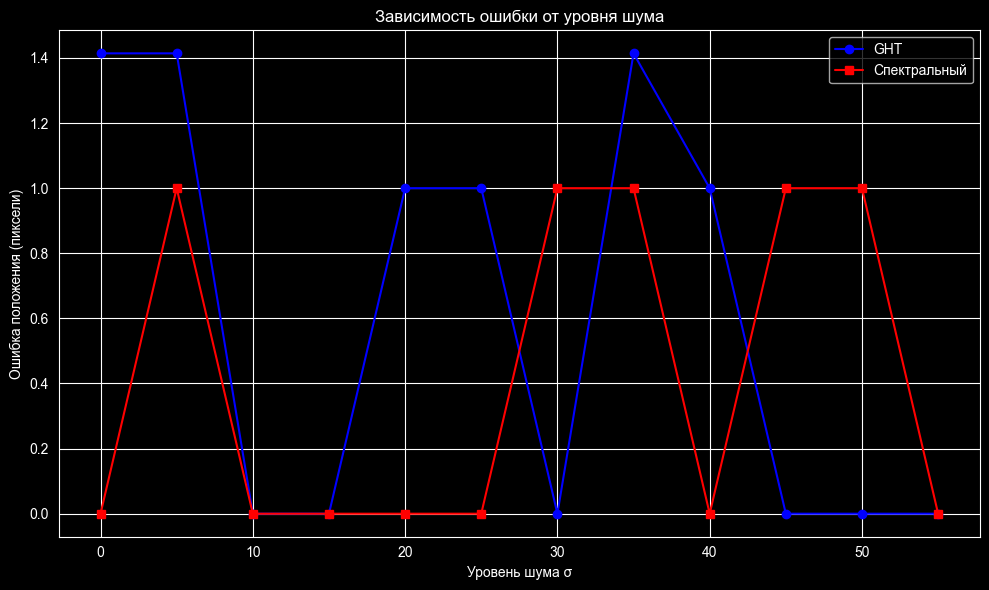

In [78]:
print("=== Исследование влияния шума ===\n")
noise_levels = np.arange(0, 60, 5)
errors_noise_ght = []
errors_noise_spec = []

for sigma in tqdm(noise_levels):
    noisy = frame_img.astype(np.float64) + np.random.normal(0, sigma, frame_img.shape)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    # GHT
    H_ns = FindGHT2(map_img, noisy, eps_deg=5)
    pos_ns = find_max_position(H_ns)
    err_ght = np.sqrt((pos_ns[0] - true_pos[0])**2 + (pos_ns[1] - true_pos[1])**2)
    errors_noise_ght.append(err_ght)

    # Спектральный
    corr_ns = spectral_correlation(map_img, noisy)
    pos_spec = np.unravel_index(np.argmax(corr_ns), corr_ns.shape)
    err_spec = np.sqrt((pos_spec[0] - true_pos[0])**2 + (pos_spec[1] - true_pos[1])**2)
    errors_noise_spec.append(err_spec)

    # print(f"Шум σ={sigma:2d}: GHT err={err_ght:.1f}, Spectral err={err_spec:.1f}")

plt.figure(figsize=(10, 6))
plt.plot(noise_levels, errors_noise_ght, 'b-o', label='GHT')
plt.plot(noise_levels, errors_noise_spec, 'r-s', label='Спектральный')
plt.xlabel('Уровень шума σ')
plt.ylabel('Ошибка положения (пиксели)')
plt.title('Зависимость ошибки от уровня шума')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Коррекция геометрических искажений

=== Коррекция шума усреднением по окну (imfilter с ones(7)) ===



100%|██████████| 12/12 [00:02<00:00,  5.20it/s]


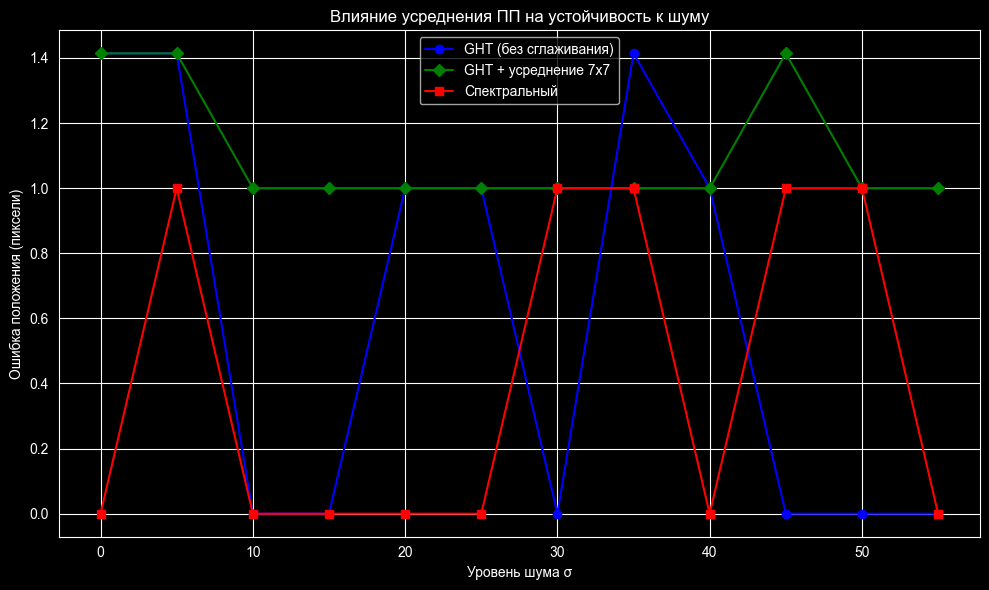

In [79]:
print("=== Коррекция шума усреднением по окну (imfilter с ones(7)) ===\n")

# Повторяем исследование шума с усреднением ПП
errors_noise_ght_smooth = []

for sigma in tqdm(noise_levels):
    noisy = frame_img.astype(np.float64) + np.random.normal(0, sigma, frame_img.shape)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    H_ns = FindGHT2(map_img, noisy, eps_deg=5)
    # Усреднение по окну 7x7 (аналог imfilter(R, ones(7)))
    H_smooth = uniform_filter(H_ns.astype(np.float64), size=7)
    pos_ns = find_max_position(H_smooth)
    err = np.sqrt((pos_ns[0] - true_pos[0])**2 + (pos_ns[1] - true_pos[1])**2)
    errors_noise_ght_smooth.append(err)

    # print(f"Шум σ={sigma:2d}: GHT+smooth err={err:.1f}")

plt.figure(figsize=(10, 6))
plt.plot(noise_levels, errors_noise_ght, 'b-o', label='GHT (без сглаживания)')
plt.plot(noise_levels, errors_noise_ght_smooth, 'g-D', label='GHT + усреднение 7x7')
plt.plot(noise_levels, errors_noise_spec, 'r-s', label='Спектральный')
plt.xlabel('Уровень шума σ')
plt.ylabel('Ошибка положения (пиксели)')
plt.title('Влияние усреднения ПП на устойчивость к шуму')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Сводные выводы

In [80]:
print("=" * 60)
print("СРАВНЕНИЕ МЕТОДОВ")
print("=" * 60)
print("""
GHT (Обобщённое преобразование Хафа):
  Сильные стороны:
  • Низкая чувствительность к изменениям условий видимости
  • Нечувствительность к отсутствию значительной части точек объекта
  • Учёт дополнительных параметров (направление градиента, кривизна)
  • Надёжнее корреляционных методов при одинаковых признаках

  Слабые стороны:
  • Чувствительность к изменениям ракурса (геометрическим искажениям)
  • Размытие отклика в ПП → снижение величины и смещение положения
  • Вычислительная сложность (двойной цикл по точкам)

Спектральный метод (корреляция через FFT):
  Сильные стороны:
  • Быстрый (O(N log N) через FFT)
  • Хорошо работает при небольших искажениях

  Слабые стороны:
  • Чувствителен к изменениям освещённости и контраста
  • Плохо работает при частичном перекрытии объекта
  • Не использует геометрические признаки

Усреднение ПП по окну (imfilter с ones(7)):
  • Восстанавливает положение и величину максимума
  • Компенсирует размытие от геометрических искажений
  • Повышает надёжность обнаружения
""")

СРАВНЕНИЕ МЕТОДОВ

GHT (Обобщённое преобразование Хафа):
  Сильные стороны:
  • Низкая чувствительность к изменениям условий видимости
  • Нечувствительность к отсутствию значительной части точек объекта
  • Учёт дополнительных параметров (направление градиента, кривизна)
  • Надёжнее корреляционных методов при одинаковых признаках

  Слабые стороны:
  • Чувствительность к изменениям ракурса (геометрическим искажениям)
  • Размытие отклика в ПП → снижение величины и смещение положения
  • Вычислительная сложность (двойной цикл по точкам)

Спектральный метод (корреляция через FFT):
  Сильные стороны:
  • Быстрый (O(N log N) через FFT)
  • Хорошо работает при небольших искажениях

  Слабые стороны:
  • Чувствителен к изменениям освещённости и контраста
  • Плохо работает при частичном перекрытии объекта
  • Не использует геометрические признаки

Усреднение ПП по окну (imfilter с ones(7)):
  • Восстанавливает положение и величину максимума
  • Компенсирует размытие от геометрических искаж